In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))
from src.config import OPERATOR_COLORS

DATA_PATH = os.path.join("..", "data", "processed", "cleaned_bd_cells.parquet")
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,}, cleaned cell records from Parquet.")

tech_matrix = pd.crosstab(df["operator"], df["radio"])

for col in ["GSM", "UMTS", "LTE"]:
    if col not in tech_matrix.columns:
        tech_matrix[col] = 0

tech_matrix["Total_Sectors"] = tech_matrix.sum(axis=1)

tech_matrix["Modernization_Index_%"] = (
    (tech_matrix["LTE"]/tech_matrix["Total_Sectors"]) * 100
).round(2)

tech_matrix["National_Infra_Share_%"] = ((tech_matrix["Total_Sectors"]/tech_matrix["Total_Sectors"].sum()) * 100).round(2)

tech_matrix = tech_matrix.sort_values(by = "Total_Sectors", ascending= False)

print("\n=== BANGLADESH CELLULAR INFRASTRUCTURE BENCHMARK ===")
display(tech_matrix[["GSM", "UMTS", "LTE", "Total_Sectors", "Modernization_Index_%", "National_Infra_Share_%"]])


Loaded 8,945, cleaned cell records from Parquet.

=== BANGLADESH CELLULAR INFRASTRUCTURE BENCHMARK ===


radio,GSM,UMTS,LTE,Total_Sectors,Modernization_Index_%,National_Infra_Share_%
operator,,,,,,
Grameenphone,401,6,2746,3153,87.09,35.25
Banglalink,222,11,2434,2667,91.26,29.82
Robi,577,0,1545,2122,72.81,23.72
Teletalk,274,75,654,1003,65.20,11.21


/tmp/ipykernel_43366/1633435100.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


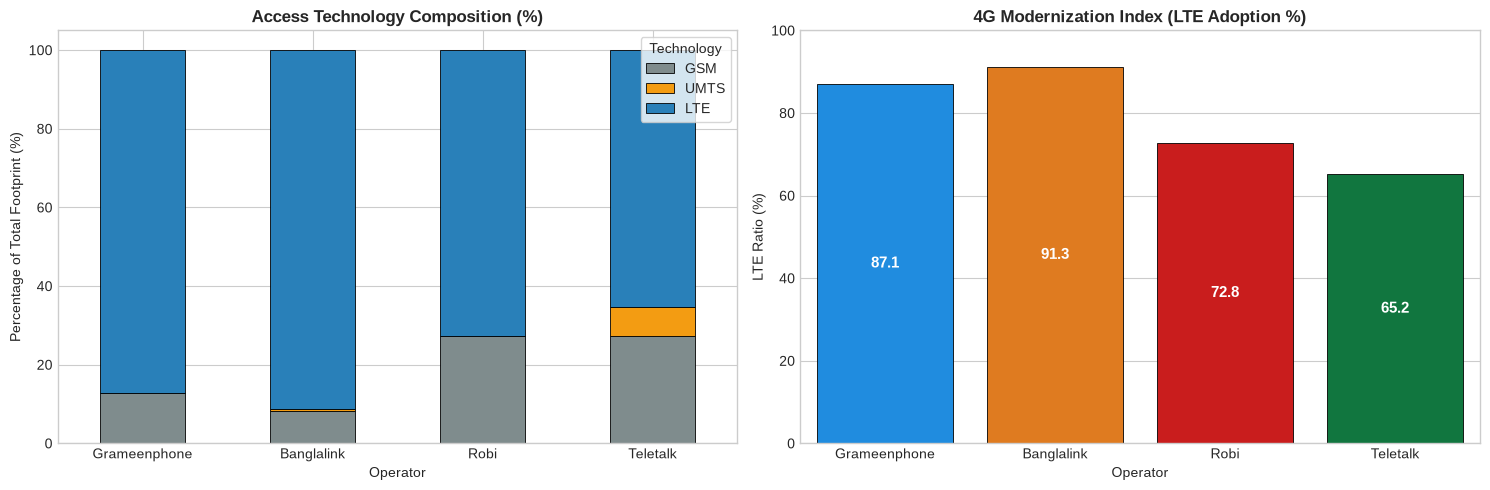

In [3]:
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

tech_props = tech_matrix[["GSM", "UMTS", "LTE"]].div(tech_matrix["Total_Sectors"], axis= 0) * 100
tech_colors = {"GSM": "#7f8c8d", "UMTS": "#f39c12", "LTE": "#2980b9"}

tech_props.plot(
    kind = "bar",
    stacked = True,
    ax= axes[0],
    color=[tech_colors[c] for c in tech_props.columns],
    edgecolor= "black",
    linewidth = 0.6
)

axes[0].set_title("Access Technology Composition (%)", fontsize= 12, weight= "bold")
axes[0].set_ylabel("Percentage of Total Footprint (%)")
axes[0].set_xlabel("Operator")
axes[0].legend(title = "Technology", frameon= True)
axes[0].tick_params(axis = "x", rotation = 0)


palette = [OPERATOR_COLORS.get(op, "#333333") for op in tech_matrix.index]
sns.barplot(
    data = tech_matrix.reset_index(),
    x = "operator",
    y = "Modernization_Index_%",
    order= tech_matrix.index,
    palette = palette,
    axes = axes[1],
    edgecolor = "black",
    linewidth = 0.6
)

axes[1].set_title("4G Modernization Index (LTE Adoption %)", fontsize = 12, weight = "bold")
axes[1].set_ylabel("LTE Ratio (%)")
axes[1].set_xlabel("Operator")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis = "x", rotation = 0)

for p in axes[1].patches:
    h = p.get_height()
    if h>0:
        axes[1].annotate(
            f"{h:.1f}",
            (p.get_x() + p.get_width() / 2., h/2),
            ha = "center", va = "center", color = "white", fontweight = "bold", fontsize = 11
        )

plt.tight_layout()
plt.show()

=== ANNUAL NEW LTE SECTORS BY OPERATOR ===


creation_year,2017,2018,2020,2021,2022,2023,2024,2025,2026,Total (2017+)
operator,,,,,,,,,,
Banglalink,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1501.0,933.0,2434.0
Grameenphone,0.0,8.0,10.0,27.0,0.0,7.0,14.0,1518.0,1162.0,2746.0
Robi,0.0,0.0,0.0,0.0,1.0,0.0,194.0,1121.0,229.0,1545.0
Teletalk,0.0,0.0,0.0,1.0,9.0,0.0,106.0,474.0,64.0,654.0


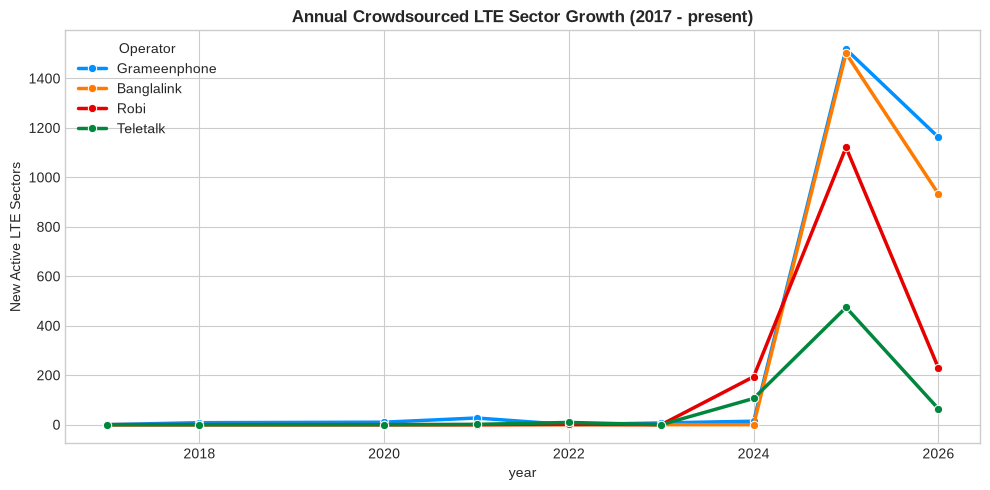

In [10]:
df["creation_year"] = df["first_seen"].dt.year

recent_rollout = df[df["creation_year"] >= 2017].groupby(
    ["creation_year", "operator", "radio"], observed = False
).size().reset_index(name="new_sectors")

lte_growth = recent_rollout[recent_rollout["radio"] == "LTE"]
lte_table = lte_growth.pivot_table(
    index="operator", 
    columns="creation_year", 
    values="new_sectors", 
    fill_value=0
)

lte_table["Total (2017+)"] = lte_table.sum(axis=1)
print("=== ANNUAL NEW LTE SECTORS BY OPERATOR ===")
display(lte_table)

plt.figure(figsize= (10, 5))


sns.lineplot(
    data = lte_growth,
    x = "creation_year",
    y = "new_sectors",
    hue_order= tech_matrix.index,
    hue = "operator",
    palette = OPERATOR_COLORS, 
    marker = "o",
    linewidth = 2.5
)

plt.title("Annual Crowdsourced LTE Sector Growth (2017 - present)", fontsize = 12, weight = "bold")
plt.xlabel("year")
plt.ylabel("New Active LTE Sectors")
plt.legend(title = "Operator")
plt.tight_layout()
plt.show()